In [2]:
import os
import yaml
import numpy as np
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [3]:
with open("../config.yaml", "r") as file:
    config = yaml.safe_load(file)

### 1. Load and check out the dataset

In [4]:
df = pd.read_csv(config["input_data"]["file1"])
df.tail()


,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
4798,4798,220000,Action Crime Thriller,NaN,9367,united states\u2013mexico barrier legs arms pa...,es,El Mariachi,El Mariachi just wants to play his guitar and ...,14.269792,...,81.0,"[{""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}]",Released,"He didn't come looking for trouble, but troubl...",El Mariachi,6.6,238,Carlos Gallardo Jaime de Hoyos Peter Marquardt...,"[{'name': 'Robert Rodriguez', 'gender': 0, 'de...",Robert Rodriguez
4799,4799,9000,Comedy Romance,NaN,72766,NaN,en,Newlyweds,A newlywed couple's honeymoon is upended by th...,0.642552,...,85.0,[],Released,A newlywed couple's honeymoon is upended by th...,Newlyweds,5.9,5,Edward Burns Kerry Bish\u00e9 Marsha Dietlein ...,"[{'name': 'Edward Burns', 'gender': 2, 'depart...",Edward Burns
4800,4800,0,Comedy Drama Romance TV Movie,http://www.hallmarkchannel.com/signedsealeddel...,231617,date love at first sight narration investigati...,en,"Signed, Sealed, Delivered","""Signed, Sealed, Delivered"" introduces a dedic...",1.444476,...,120.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,NaN,"Signed, Sealed, Delivered",7.0,6,Eric Mabius Kristin Booth Crystal Lowe Geoff G...,"[{'name': 'Carla Hetland', 'gender': 0, 'depar...",Scott Smith
4801,4801,0,NaN,http://shanghaicalling.com/,126186,NaN,en,Shanghai Calling,When ambitious New York attorney Sam is sent t...,0.857008,...,98.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,A New Yorker in Shanghai,Shanghai Calling,5.7,7,Daniel Henney Eliza Coupe Bill Paxton Alan Ruc...,"[{'name': 'Daniel Hsia', 'gender': 2, 'departm...",Daniel Hsia
4802,4802,0,Documentary,NaN,25975,obsession camcorder crush dream girl,en,My Date with Drew,Ever since the second grade when he first saw ...,1.929883,...,90.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,NaN,My Date with Drew,6.3,16,Drew Barrymore Brian Herzlinger Corey Feldman ...,"[{'name': 'Clark Peterson', 'gender': 2, 'depa...",Brian Herzlinger


In [5]:
df.columns

Index(['index', 'budget', 'genres', 'homepage', 'id', 'keywords',
       'original_language', 'original_title', 'overview', 'popularity',
       'production_companies', 'production_countries', 'release_date',
       'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title',
       'vote_average', 'vote_count', 'cast', 'crew', 'director'],
      dtype='str')

In [6]:
df['release_date'].unique()

<StringArray>
['2009-12-10', '2007-05-19', '2015-10-26', '2012-07-16', '2012-03-07',
 '2007-05-01', '2010-11-24', '2015-04-22', '2009-07-07', '2016-03-23',
 ...
 '1972-03-12', '2004-04-11', '2012-01-20', '1995-09-09', '2004-10-08',
 '2005-03-12', '1992-09-04', '2011-12-26', '2013-10-13', '2012-05-03']
Length: 3281, dtype: str

In [7]:
df['budget'].unique()

array([237000000, 300000000, 245000000, 250000000, 260000000, 258000000,
       280000000, 270000000, 200000000, 255000000, 225000000, 220000000,
       380000000, 215000000, 180000000, 207000000, 209000000, 150000000,
       210000000, 170000000, 190000000, 195000000, 105000000, 185000000,
       175000000, 140000000, 176000003, 178000000, 145000000,  27000000,
       165000000, 160000000,  15000000,  38000000, 155000000, 149000000,
       144000000,  70000000, 100000000, 139000000, 135000000, 130000000,
       137000000, 120000000, 132000000, 110000000, 125000000, 127500000,
       127000000, 103000000,  65000000, 123000000, 115000000, 117000000,
       113000000,  97250400, 116000000, 112000000,  93000000, 107000000,
               0, 133000000, 108000000, 126000000,  90000000, 102000000,
        80000000,  84000000,  99000000,  10000000,  98000000,  94000000,
        85000000,  92000000,  95000000,  79000000,  75000000,  88000000,
        68000000,  20000000,  87000000,  60000000, 

In [4]:
display(df.describe)

<bound method NDFrame.describe of       index     budget                                    genres  \
0         0  237000000  Action Adventure Fantasy Science Fiction   
1         1  300000000                  Adventure Fantasy Action   
2         2  245000000                    Action Adventure Crime   
3         3  250000000               Action Crime Drama Thriller   
4         4  260000000          Action Adventure Science Fiction   
...     ...        ...                                       ...   
4798   4798     220000                     Action Crime Thriller   
4799   4799       9000                            Comedy Romance   
4800   4800          0             Comedy Drama Romance TV Movie   
4801   4801          0                                       NaN   
4802   4802          0                               Documentary   

                                               homepage      id  \
0                           http://www.avatarmovie.com/   19995   
1          http

In [5]:
df.isna().sum()

index                      0
budget                     0
genres                    28
homepage                3091
id                         0
keywords                 412
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
cast                      43
crew                       0
director                  30
dtype: int64

In [6]:
print(df.columns.tolist())

['index', 'budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count', 'cast', 'crew', 'director']


In [7]:
target = df['director']
target

0           James Cameron
1          Gore Verbinski
2              Sam Mendes
3       Christopher Nolan
4          Andrew Stanton
              ...        
4798     Robert Rodriguez
4799         Edward Burns
4800          Scott Smith
4801          Daniel Hsia
4802     Brian Herzlinger
Name: director, Length: 4803, dtype: str

In [8]:
target.nunique()

2349

### 2. Drop irrelevant columns

In [9]:
DROP_COLS = ["index", "id", "homepage", "tagline", "overview",
             "keywords", "original_title", "title", "original_language",
             "status", "crew", "revenue"]  # revenue would be data leakage
df.drop(columns=DROP_COLS, inplace=True)
df.shape

(4803, 12)

### 3. Clean the target variable (budget)

Budget=0 means "not reported", not actually zero — remove them

Rows after removing zero budgets: 3766


<Axes: >

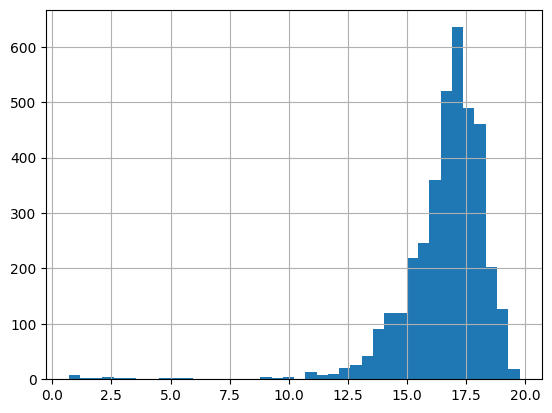

In [10]:
df = df[df["budget"] > 0].copy()
print(f"Rows after removing zero budgets: {len(df)}")

# Log-transform to reduce skew
df["budget_log"] = np.log1p(df["budget"])

# Quick sanity check
df["budget_log"].hist(bins=40)

The histogramm is more or less bell shaped. This is good.

### 4. Handle missing values

In [11]:
# Drop rows where director is missing
df.dropna(subset=["director"], inplace=True)

# Parse release_date HERE before anything else touches it
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["release_year"] = df["release_date"].dt.year
df.dropna(subset=["release_date"], inplace=True)   # drops the 1 bad row
df.drop(columns=["release_date"], inplace=True)

# Fill remaining missing values
df["genres"] = df["genres"].fillna("")
df["cast"] = df["cast"].fillna("")
df["runtime"] = df["runtime"].fillna(df["runtime"].median())

print(df.isna().sum())  # should all be 0

budget                  0
genres                  0
popularity              0
production_companies    0
production_countries    0
runtime                 0
spoken_languages        0
vote_average            0
vote_count              0
cast                    0
director                0
budget_log              0
release_year            0
dtype: int64


### 5. Parse & engineer features

In [12]:
# Step 5 — genres fix
# Fix multi-word genre names BEFORE splitting
df["genres"] = df["genres"].fillna("") \
    .str.replace("Science Fiction", "SciFi") \
    .str.replace("TV Movie", "TVMovie")

df["genres_list"] = df["genres"].str.split()

mlb = MultiLabelBinarizer()
genre_dummies = pd.DataFrame(
    mlb.fit_transform(df["genres_list"]),
    columns=["genre_" + g.lower() for g in mlb.classes_],
    index=df.index
)
df = pd.concat([df, genre_dummies], axis=1)
df.drop(columns=["genres", "genres_list"], inplace=True)

# Cast: count members
df["cast_count"] = df["cast"].fillna("").str.split().apply(len)
df.drop(columns=["cast"], inplace=True)

print(df.shape)
print(df.isna().sum())

(3759, 32)
budget                  0
popularity              0
production_companies    0
production_countries    0
runtime                 0
spoken_languages        0
vote_average            0
vote_count              0
director                0
budget_log              0
release_year            0
genre_action            0
genre_adventure         0
genre_animation         0
genre_comedy            0
genre_crime             0
genre_documentary       0
genre_drama             0
genre_family            0
genre_fantasy           0
genre_foreign           0
genre_history           0
genre_horror            0
genre_music             0
genre_mystery           0
genre_romance           0
genre_scifi             0
genre_tvmovie           0
genre_thriller          0
genre_war               0
genre_western           0
cast_count              0
dtype: int64


### 6. Encode director (the hypothesis variable) 

In [13]:
# Frequency encoding: how many films has this director made in the dataset?
director_freq = df["director"].value_counts()
df["director_freq"] = df["director"].map(director_freq)

# Label encoding: numeric ID per director (for tree-based models)
le = LabelEncoder()
df["director_label"] = le.fit_transform(df["director"])

df.drop(columns=["director"], inplace=True)

### 7. Train/Test split

In [14]:
TARGET = "budget_log"
X = df.drop(columns=["budget", "budget_log", 
                      "production_companies", "production_countries", 
                      "spoken_languages"])  # still unparsed strings
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (3007, 28) | Test: (752, 28)


### 8. Scale numeric features

In [15]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),  # fit only on train, transform test!
    columns=X_test.columns,
    index=X_test.index
)

print(X_train_scaled.describe().round(2))

       popularity  runtime  vote_average  vote_count  release_year  \
count     3007.00  3007.00       3007.00     3007.00       3007.00   
mean        -0.00    -0.00          0.00        0.00          0.00   
std          1.00     1.00          1.00        1.00          1.00   
min         -0.73    -5.25         -6.45       -0.63         -6.05   
25%         -0.50    -0.69         -0.55       -0.55         -0.33   
50%         -0.24    -0.16          0.07       -0.36          0.22   
75%          0.22     0.51          0.69        0.08          0.69   
max         23.63    10.98          2.35        9.49          1.09   

       genre_action  genre_adventure  genre_animation  genre_comedy  \
count       3007.00          3007.00          3007.00       3007.00   
mean          -0.00            -0.00            -0.00         -0.00   
std            1.00             1.00             1.00          1.00   
min           -0.61            -0.49            -0.24         -0.72   
25%           

### 9. Save

In [16]:
save_dir = "../data/clean"
os.makedirs(save_dir, exist_ok=True)  # creates folder if it doesn't exist

X_train.to_csv(f"{save_dir}/H2_X_train.csv", index=False)
X_test.to_csv(f"{save_dir}/H2_X_test.csv", index=False)
y_train.to_frame().to_csv(f"{save_dir}/H2_y_train.csv", index=False)
y_test.to_frame().to_csv(f"{save_dir}/H2_y_test.csv", index=False)
X_train_scaled.to_csv(f"{save_dir}/H2_X_train_scaled.csv", index=False)
X_test_scaled.to_csv(f"{save_dir}/H2_X_test_scaled.csv", index=False)

print("✅ All files saved to ../data/clean/")

✅ All files saved to ../data/clean/
